# Predict Customer Churn #
This is my first Kaggle competition entry, working on on season 6 episode 3 of the playground predictions series - Predict Customer Churn

In [135]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

Let's import our data as pandas dataframes for easy manipulation.

In [111]:
train_df = pd.read_csv("data/train.csv")
valid_df = pd.read_csv("data/test.csv")

N_tr = len(train_df)
N_te = len(valid_df)

print(f"Training Data Length: {N_tr}\nTest Data Length : {N_te}")

Training Data Length: 594194
Test Data Length : 254655


Now check that whether any data is missing, this may take a while...

In [34]:
invalid_entries = {column: 0 for column in train_df.columns}
for i in range(N_tr):
    for col in train_df.columns:
        invalid_entries[col] += pd.isnull(train_df.loc[i, col]) # Check train dataframe for null values.
        if i < N_te and col != "Churn":
            invalid_entries[col] += pd.isnull(valid_df.loc[i, col]) # Check test dataframe as well.
print(invalid_entries)

KeyboardInterrupt: 

No problems, a miracle! Now we need to clean the data up, categorical data is no good to our model, so we'll use a label encoder to convert our categorical data to data we can use in our model. We use the pd.get_dummies method for this, which converts a categorical data column into several boolean data columns, with the downside that this makes the data significantly harder to read. We should also normalise our data to prevent larger raw values from having a disproportionate impact on our output.

In [43]:
def normalise(df: pd.DataFrame) -> pd.DataFrame:
    types = df.dtypes
    cols =[col for col in df.columns if types[col] != "str" and col != "id"]
    for col in cols:
        df_col = df[col]
        df[col] = (df_col-df_col.mean())/df_col.std()
    return df

In [44]:
def encode_labels(df: pd.DataFrame) -> pd.DataFrame:
    le = LabelEncoder()
    cols = [col for col in df.columns if df.dtypes[col] == "str"]
    for col in cols:
        df[col] = pd.factorize(df[col])[0]
    return df

In [45]:
def encode_one_hot(df: pd.DataFrame) -> pd.DataFrame:
    types = df.dtypes
    df = pd.get_dummies(df, columns=[col for col in df.columns if types[col] == "str"])
    return df

In [120]:
def prepare_data(df):
    d = {"Yes": True, "No": False}
    y = df["Churn"].map(d)
    x = df.iloc[:, :-1]

    x = encode_labels(normalise(x))
    return pd.concat([x, y], axis=1)

In [121]:
train_df = prepare_data(train_df)

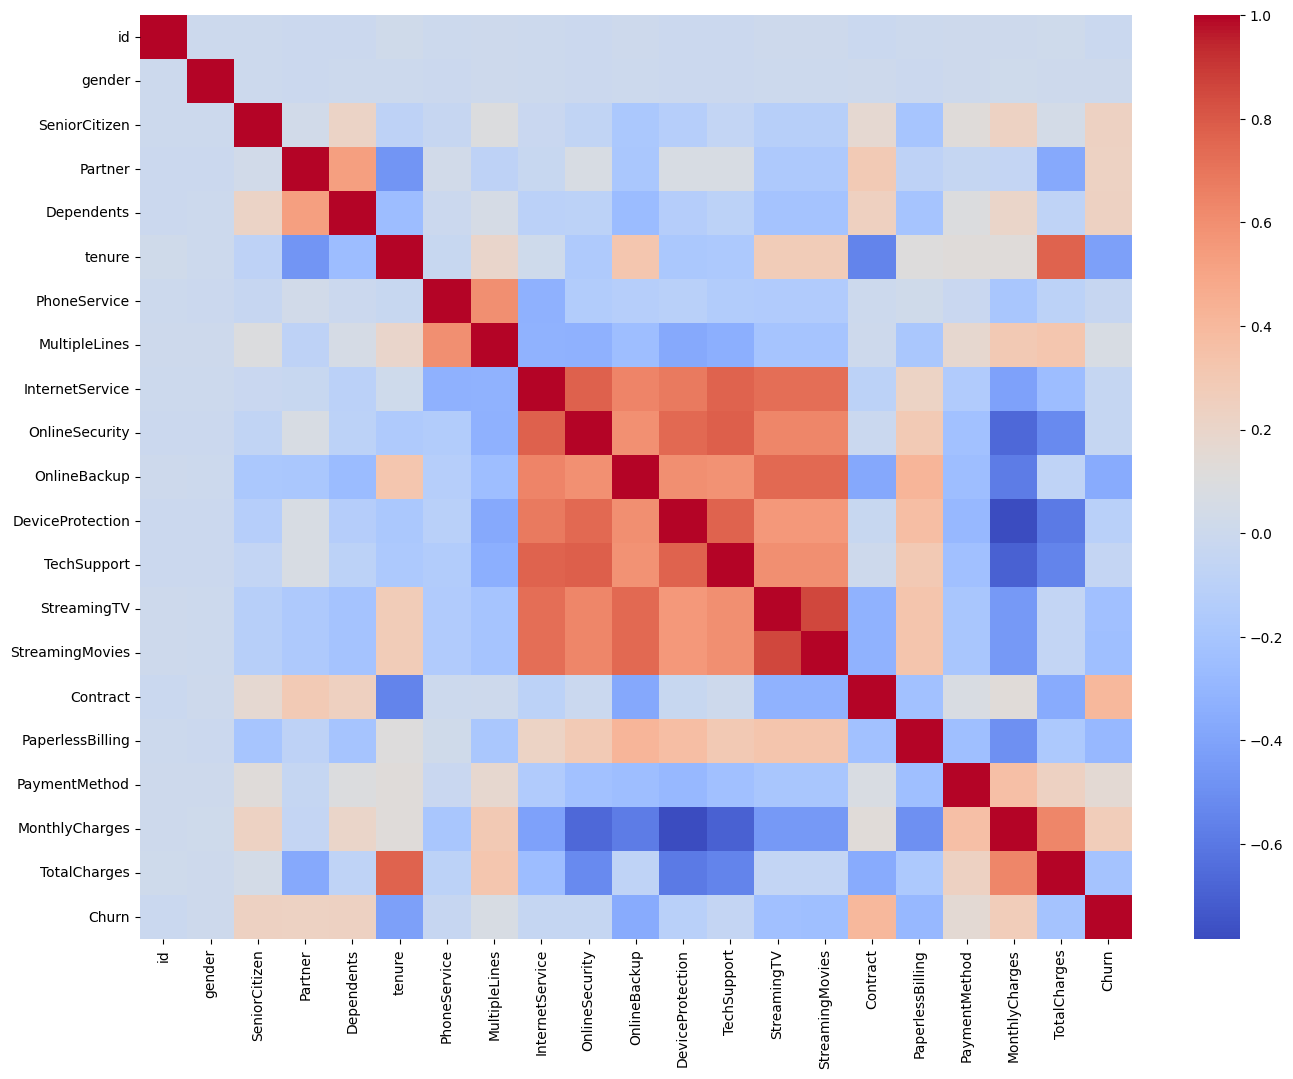

In [122]:
corr_matrix = train_df.corr()
plt.figure(figsize=(16,12))
sns.heatmap(corr_matrix, cmap="coolwarm")
plt.show()

The most important row to consider here is of course 'Churn', and we can see fair correlation with contract type and, along with some other properties

We don't have access to the "Churn" variable for the data in test.csv, so we will use a subset of our training database as our test data during the training of the model. This is important to avoid overfitting and ensure appropriate progress of the model, and will help to diagnose problems in the future.

In [239]:
def train_test_split(df, frac = 0.2):
    test = df.sample(frac = frac, axis = 0)
    train = df.drop(index=test.index)
    x_train = torch.tensor(train.iloc[:,1:-1].values).to(torch.float32)
    y_train = torch.tensor(train.iloc[:,-1].values).to(torch.float32)
    y_train = torch.tensor(train.iloc[:,-1].values).to(torch.float32).requires_grad_(True)
    x_test = torch.tensor(test.iloc[:,1:-1].values, requires_grad=True).to(torch.float32)
    y_test = torch.tensor(test.iloc[:,-1].values).to(torch.float32).requires_grad_(True)
    return x_train, y_train, x_test, y_test

In [240]:
x_train, y_train, x_test, y_test = train_test_split(train_df)

Now let's define a neural network using pytorch, with an MLP structure due to our data being tabulated. Our input size is 19, 1 for each column in our dataframe, except 'id' and 'Churn', then we have a hidden layer with 38 nodes, and finally an output layer with a single output, this is our probability of churn for our input.

In [164]:
class mlp_V1(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.fc1 = nn.Linear(19, 38)
        self.fc2 = nn.Linear(38, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.fc2(x)
        return x

In [272]:
def loss(predictions, y):
    predictions = predictions.squeeze()
    e2 = torch.sub(predictions, y)
    e2 = e2**2
    return torch.mean(e2)

In [ ]:
def train_model(model: mlp_V1, x_train, y_train, x_test, y_test, lr, steps, batch_size = 32):
    optimiser = optim.SGD(params=model.parameters(), lr = lr)
    train_loss = np.zeros(steps)
    test_loss = np.zeros(steps)
    for i in range(steps):
        optimiser.zero_grad()

        N = len(x_train)
        predictions = model(x_train).requires_grad_(True)
        train_losses = loss(predictions, y_train)
        train_loss[i] = train_losses

        test_predictions = model(x_test)
        train_losses.backward()
        optimiser.step()

        model.eval()
        with torch.no_grad():
            test_loss[i] = loss(test_predictions, y_test)
        model.train()
    print("{:0.5f} {:0.5f}".format(train_loss[-1], test_loss[-1]))
    return model, train_loss, test_loss


In [247]:
def plot_loss(train_loss, test_loss):
    plt.plot(train_loss)
    plt.plot(test_loss)
    plt.show()

In [ ]:
model = mlp_V1()
model, trl, tel = train_model(model, x_train, y_train, x_test, y_test, 0.01, 1000)
plot_loss(trl, tel)


0.30798 0.30783
0.25983 0.25968
0.23555 0.23541
0.22162 0.22150
0.21242 0.21234
0.20558 0.20553
0.20004 0.20004
0.19534 0.19537
0.19122 0.19129
0.18756 0.18766
0.18427 0.18441
0.18129 0.18146
0.17857 0.17877
0.17609 0.17632
0.17381 0.17406
0.17171 0.17198
0.16977 0.17006
0.16796 0.16826
0.16627 0.16659
0.16469 0.16503
0.16321 0.16356
0.16182 0.16217
0.16050 0.16086
0.15925 0.15962
0.15807 0.15845
0.15694 0.15733
0.15587 0.15626
0.15485 0.15523
0.15387 0.15426
0.15293 0.15332
0.15202 0.15241
0.15115 0.15155
0.15032 0.15071
0.14951 0.14990
0.14873 0.14912
0.14798 0.14837
0.14725 0.14764
0.14655 0.14693
0.14587 0.14625
0.14520 0.14558
0.14456 0.14493
0.14394 0.14431
0.14333 0.14370
0.14274 0.14310
0.14217 0.14253
0.14161 0.14197
0.14107 0.14142
0.14054 0.14089
0.14003 0.14037
0.13953 0.13986
0.13904 0.13937
0.13856 0.13888
0.13810 0.13841
0.13764 0.13795
0.13720 0.13751
0.13677 0.13707
0.13634 0.13664
0.13593 0.13622
0.13553 0.13582
0.13514 0.13542
0.13475 0.13503
0.13438 0.13465
0.13401 